# Four Layers for 2022 — Car, Bus, Taxi-type, Rail

Moves the survey-only two-mode matrix of `THS_2017_two_mode_matrix.ipynb` to a **2022 base** and splits it into four layers: **car**, **bus** (survey Public Bus + Matronit calibrated to RavKav × OnBoard), **taxi-type** (Special / Group Taxi, `mainmode` 5 / 8 — kept separate from bus, review §9) and **rail**. The vintage conventions are those of `Vintage_alignment_2022.ipynb` (TRANSIT_DEMAND_PLAN step 5), applied at TAZ level:

| Layer | 2018 → 2022 treatment |
|---|---|
| **Car** (survey 2018) | Furnessed to grown margins: origins × population growth, destinations × employment growth, one grand total set by the origin side |
| **Bus**, cells whose origin × segment took RavKav volumes | already at the May 2022 ticketing level — untouched (the anchor) |
| **Bus**, coverage-guarded origin × segment cells (survey volume kept) | × the origin population growth factor of their TAZ |
| **Taxi-type** (survey 2018) | Furnessed like car; its own `taxi_2022_*` files |
| **Rail** (survey 2018, door-to-door) | × 54.7 / 69.0 = 0.793, the national heavy-rail ridership change 2019 → 2022 used throughout the repository (2018 taken at the 2019 level) |

**Growth factors** $g = (X_{2025} / X_{2020})^{4/5}$ from `Input/Zonal_2020.csv` (observed) and `Input/Zonal_BU_2025.csv` (forecast) — the 2020 → 2025 annual rate over the four years 2018 → 2022. At TAZ level the factor is used only where the 2020 base is at least 500 (population for origins, employment for destinations); smaller zones take their **superzone's** factor, and origins of pure-employment zones (population < 500, employment ≥ 500) take the employment factor, as in the area-level version. The output folder keeps its historical name `three_mode_2022/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)
IN, OUT = 'Output/ths2017/two_mode', 'Output/ths2017/three_mode_2022'
os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

def load_sq(path):
    m = pd.read_csv(path, index_col=0); m.index = m.index.astype(int); m.columns = m.columns.astype(int); return m
car18 = load_sq(f'{IN}/car_taz.csv'); TAZ = car18.index.values; N = len(TAZ)
bus_cal = load_sq(f'{IN}/bus_calibrated_taz.csv').reindex(index=TAZ, columns=TAZ).fillna(0)
taxi18 = load_sq(f'{IN}/taxi_survey_taz.csv').reindex(index=TAZ, columns=TAZ).fillna(0)
rail18 = load_sq(f'{IN}/rail_survey_taz.csv').reindex(index=TAZ, columns=TAZ).fillna(0)
seg_tbl = pd.read_csv(f'{IN}/bus_calibration_factors_segments.csv')        # segmented coverage rule: guarded origin SZ × destination segment
SEG = ['local', 'inter-SZ, corridor-bound', 'inter-SZ, other']

KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs') else pd.read_csv(KEYS_LFS, encoding='windows-1255')
kd = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')
sz_of = kd['SZ_NEW'].reindex(TAZ).values; SZ = sorted(set(sz_of))
M_sz = np.zeros((N, len(SZ))); M_sz[np.arange(N), [SZ.index(z) for z in sz_of]] = 1
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA)))
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, AREA.index(area_of[t])] = 1
corridor = np.isin(TAZ, sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ'].values)
corr_sz = sorted({z for z, f in zip(sz_of, corridor) if f})                 # same definition as in the two-mode notebook
col = np.array([SZ.index(z) for z in sz_of])
seg_idx = np.where(sz_of[:, None] == sz_of[None, :], 0, np.where(np.isin(sz_of, corr_sz)[None, :], 1, 2))
G = seg_tbl.pivot(index='origin SZ', columns='segment', values='guarded').reindex(index=SZ, columns=SEG).fillna(False).values.astype(bool)
guarded_cell = G[col[:, None], seg_idx]                                       # bus cells still at survey 2018 volume (ticketing under-coverage)
print(f"2018-vintage inputs: car {car18.values.sum():,.0f}, calibrated bus {bus_cal.values.sum():,.0f} "
      f"(of which {bus_cal.values[guarded_cell].sum():,.0f} in {int(G.sum())} coverage-guarded origin × segment cells at survey 2018 level), "
      f"taxi-type {taxi18.values.sum():,.0f}, rail {rail18.values.sum():,.0f}")

2018-vintage inputs: car 1,283,589, calibrated bus 126,117 (of which 57,051 in 28 coverage-guarded origin × segment cells at survey 2018 level), taxi-type 18,266, rail 5,109


## 1. Growth factors 2018 → 2022 at TAZ level

In [2]:
BASE_MIN = 500
z20 = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
z25 = pd.read_csv('Input/Zonal_BU_2025.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
p20, p25 = z20['POPULATION'].fillna(0).values, z25['POPULATION'].fillna(0).values
e20, e25 = z20['EMPL_TOT'].fillna(0).values, z25['EMPL_TOT'].fillna(0).values
def g(x25, x20): return np.divide(x25, x20, out=np.ones_like(x25, dtype=float), where=x20 > 0) ** (4 / 5)
g_pop_taz, g_emp_taz = g(p25, p20), g(e25, e20)
g_pop_sz = g(M_sz.T @ p25, M_sz.T @ p20)[[SZ.index(z) for z in sz_of]]
g_emp_sz = g(M_sz.T @ e25, M_sz.T @ e20)[[SZ.index(z) for z in sz_of]]
g_o = np.where(p20 >= BASE_MIN, g_pop_taz, np.where(e20 >= BASE_MIN, g_emp_taz, g_pop_sz))
g_d = np.where(e20 >= BASE_MIN, g_emp_taz, g_emp_sz)
src_o = np.where(p20 >= BASE_MIN, 'TAZ population', np.where(e20 >= BASE_MIN, 'TAZ employment (pure-employment zone)', 'superzone population'))
src_d = np.where(e20 >= BASE_MIN, 'TAZ employment', 'superzone employment')
gf = pd.DataFrame({'TAZ': TAZ, 'SZ': sz_of, 'corridor': corridor, 'pop_2020': p20, 'pop_2025': p25, 'empl_2020': e20, 'empl_2025': e25,
                   'g_origin': g_o, 'origin basis': src_o, 'g_dest': g_d, 'dest basis': src_d})
gf.to_csv(f'{OUT}/growth_factors_taz_2018_2022.csv', index=False, float_format='%.4f')
print("origin factor basis:", pd.Series(src_o).value_counts().to_dict()); print("destination factor basis:", pd.Series(src_d).value_counts().to_dict())
w_o, w_d = car18.sum(axis=1).values, car18.sum(axis=0).values
print(f"origin factors: p5 {np.percentile(g_o, 5):.3f}, median {np.median(g_o):.3f}, p95 {np.percentile(g_o, 95):.3f}, max {g_o.max():.3f}; car-trip-weighted mean {np.average(g_o, weights=w_o):.3f}")
print(f"destination factors: p5 {np.percentile(g_d, 5):.3f}, median {np.median(g_d):.3f}, p95 {np.percentile(g_d, 95):.3f}, max {g_d.max():.3f}; car-trip-weighted mean {np.average(g_d, weights=w_d):.3f}")
print("\nlargest TAZ origin factors (population ≥ 500):")
print(gf[gf['origin basis'] == 'TAZ population'].sort_values('g_origin', ascending=False).head(6)[['TAZ', 'SZ', 'corridor', 'pop_2020', 'pop_2025', 'g_origin']].round(3).to_string(index=False))

origin factor basis: {'TAZ population': 606, 'superzone population': 100, 'TAZ employment (pure-employment zone)': 72}
destination factor basis: {'TAZ employment': 506, 'superzone employment': 272}
origin factors: p5 0.942, median 1.050, p95 1.161, max 4.016; car-trip-weighted mean 1.055
destination factors: p5 0.961, median 1.088, p95 1.300, max 4.016; car-trip-weighted mean 1.135

largest TAZ origin factors (population ≥ 500):
 TAZ  SZ  corridor  pop_2020  pop_2025  g_origin
3910  39     False      5162      7026     1.280
3912  39     False      6243      8495     1.279
3911  39     False      8042     10881     1.274
2421  24      True      1516      2033     1.265
2415  24      True      1725      2313     1.264
2412  24      True      3223      4320     1.264


## 2. Car 2022 — Furness to grown margins

In [3]:
def furness(seed, row_t, col_t, iters=500, tol=1e-6):
    m = np.asarray(seed, float).copy()
    for it in range(iters):
        rs = m.sum(axis=1); m *= np.divide(row_t, rs, out=np.zeros_like(row_t), where=rs > 0)[:, None]
        cs = m.sum(axis=0); m *= np.divide(col_t, cs, out=np.ones_like(col_t), where=cs > 0)[None, :]
        if max(np.abs(m.sum(axis=1) - row_t).max(), np.abs(m.sum(axis=0) - col_t).max()) < tol: break
    return m, it + 1
def grow(seed):
    row_t = seed.sum(axis=1) * g_o; col_t = seed.sum(axis=0) * g_d
    col_t = col_t * row_t.sum() / col_t.sum()
    out, it = furness(seed, row_t, col_t)
    return out, it, np.abs(out.sum(axis=1) - row_t).max(), np.abs(out.sum(axis=0) - col_t).max()
car22, it, er, ec = grow(car18.values)
print(f"car 2018 → 2022: {car18.values.sum():,.0f} → {car22.sum():,.0f} ({car22.sum() / car18.values.sum() - 1:+.1%}); Furness {it} iterations, max margin error rows {er:.1e} / cols {ec:.1e}")

car 2018 → 2022: 1,283,589 → 1,353,798 (+5.5%); Furness 261 iterations, max margin error rows 9.7e-07 / cols 5.5e-12


## 3. Bus 2022 — calibrated bus (anchor) with guarded segments grown; taxi-type grown separately

Taxi-type modes (Special / Group Taxi, `mainmode` 5 / 8) are **not** part of the bus matrix any more (review §9): they are a separate layer with its own outputs, so that the bus layer is the RavKav-ticketed services only.

In [4]:
bus22 = bus_cal.values * np.where(guarded_cell, g_o[:, None], 1.0)     # guarded cells (survey 2018 volume) grow with their origin factor; calibrated cells are the 2022 anchor
taxi22, it_t, er_t, ec_t = grow(taxi18.values)
print(f"calibrated bus: RavKav-anchored cells {bus_cal.values[~guarded_cell].sum():,.0f} (unchanged, May 2022); guarded cells {bus_cal.values[guarded_cell].sum():,.0f} → {bus22[guarded_cell].sum():,.0f} "
      f"(trip-weighted factor {bus22[guarded_cell].sum() / bus_cal.values[guarded_cell].sum():.3f}); bus 2022 total {bus22.sum():,.0f}")
print(f"taxi-type (separate layer): {taxi18.values.sum():,.0f} → {taxi22.sum():,.0f} ({it_t} Furness iterations; largest row-target shortfall {er_t:.0f} trips = {er_t / taxi22.sum():.1%} of the layer, columns exact — a sparse matrix whose few cells in zero-growth columns cannot reach their row target)")

calibrated bus: RavKav-anchored cells 69,066 (unchanged, May 2022); guarded cells 57,051 → 60,587 (trip-weighted factor 1.062); bus 2022 total 129,653
taxi-type (separate layer): 18,266 → 19,359 (500 Furness iterations; largest row-target shortfall 64 trips = 0.3% of the layer, columns exact — a sparse matrix whose few cells in zero-growth columns cannot reach their row target)


## 4. Rail 2022 — survey rail scaled by the national rail ridership change; station-based alternative

In [5]:
RAIL_FACTOR = 54.7 / 69.0
rail22 = rail18.values * RAIL_FACTOR
train19 = pd.read_csv('Output/train/train_od_taz_6_9.csv', index_col=0); train19.index = train19.index.astype(int); train19.columns = train19.columns.astype(int)
train22 = train19 * RAIL_FACTOR
train22.index.name = 'OriginTAZ'; train22.to_csv(f'{OUT}/rail_station_smartcard_2022_taz.csv', float_format='%.6g')
sub_taz = set(sub_key['TAZ'])
in_sub = lambda m: m.loc[[t for t in m.index if t in sub_taz], [t for t in m.columns if t in sub_taz]].values.sum()
print(f"rail (survey, door-to-door, both ends in the study area): {rail18.values.sum():,.0f} (2018) → {rail22.sum():,.0f} (2022, × {RAIL_FACTOR:.3f})")
print(f"alternative — 2019 smartcard station-to-station matrix × {RAIL_FACTOR:.3f}: {train19.values.sum():,.0f} → {train22.values.sum():,.0f} between the {len(train19)} northern stations "
      f"(of which {in_sub(train22):,.0f} with both stations in the 205-TAZ sub-area vs {in_sub(pd.DataFrame(rail22, index=TAZ, columns=TAZ)):,.0f} survey rail trips there)")

rail (survey, door-to-door, both ends in the study area): 5,109 (2018) → 4,050 (2022, × 0.793)
alternative — 2019 smartcard station-to-station matrix × 0.793: 5,535 → 4,388 between the 19 northern stations (of which 763 with both stations in the 205-TAZ sub-area vs 104 survey rail trips there)


## 5. Outputs and summary

In [6]:
def save(X, name, labels, idx):
    df_ = pd.DataFrame(X, index=labels, columns=labels); df_.index.name = idx; df_.to_csv(f'{OUT}/{name}.csv', float_format='%.6g')
MATS22 = {'car': car22, 'bus': bus22, 'taxi': taxi22, 'rail': rail22}
for k, X in MATS22.items():
    save(X, f'{k}_2022_taz', TAZ, 'orig_taz'); save(M_sz.T @ X @ M_sz, f'{k}_2022_sz', SZ, 'origin_sz'); save(M_area.T @ X @ M_area, f'{k}_2022_area', AREA, 'AggAreaCode')
save(car22 + bus22 + taxi22 + rail22, 'all_modes_2022_taz', TAZ, 'orig_taz')
for stale in ['bus_2022_excl_taxi_taz.csv', 'all_three_modes_2022_taz.csv']:                  # first-version files whose content moved
    if os.path.exists(f'{OUT}/{stale}'): os.remove(f'{OUT}/{stale}')

cls = np.where(corridor[:, None] & corridor[None, :], 'corridor→corridor', np.where(corridor[:, None] & ~corridor[None, :], 'corridor→outside',
      np.where(~corridor[:, None] & corridor[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']
MATS18 = {'car': car18.values, 'bus': bus_cal.values, 'taxi': taxi18.values, 'rail': rail18.values}
rows = []
for k in CLASSES + ['all']:
    m = np.ones_like(cls, dtype=bool) if k == 'all' else cls == k
    r = {'class': k}
    for mode in ['car', 'bus', 'taxi', 'rail']:
        r[f'{mode} 2018'] = MATS18[mode][m].sum(); r[f'{mode} 2022'] = MATS22[mode][m].sum()
    for yr, M in [('2018', MATS18), ('2022', MATS22)]:
        tot = sum(M[x][m].sum() for x in M)
        for mode in ['bus', 'taxi', 'rail']: r[f'{mode} share {yr}'] = M[mode][m].sum() / tot
    rows.append(r)
summ = pd.DataFrame(rows).set_index('class'); summ.to_csv(f'{OUT}/summary_2018_2022.csv', float_format='%.4f')
sz_tbl = pd.DataFrame({'origin SZ': SZ, 'guarded segments (bus at survey volume)': G.sum(axis=1),
                       'car 2018': M_sz.T @ car18.values.sum(axis=1), 'car 2022': M_sz.T @ car22.sum(axis=1),
                       'bus 2018': M_sz.T @ MATS18['bus'].sum(axis=1), 'bus 2022': M_sz.T @ bus22.sum(axis=1),
                       'taxi 2018': M_sz.T @ taxi18.values.sum(axis=1), 'taxi 2022': M_sz.T @ taxi22.sum(axis=1),
                       'rail 2018': M_sz.T @ rail18.values.sum(axis=1), 'rail 2022': M_sz.T @ rail22.sum(axis=1)})
sz_tbl['transit share 2022 (bus + rail)'] = (sz_tbl['bus 2022'] + sz_tbl['rail 2022']) / sz_tbl[['car 2022', 'bus 2022', 'taxi 2022', 'rail 2022']].sum(axis=1)
sz_tbl.to_csv(f'{OUT}/summary_sz_2018_2022.csv', index=False, float_format='%.4f')
print(f"outputs written to {OUT}/  (car / bus / taxi / rail × taz / sz / area, growth factors, summaries)")
summ.round(3)

outputs written to Output/ths2017/three_mode_2022/  (car / bus / taxi / rail × taz / sz / area, growth factors, summaries)


,car 2018,car 2022,bus 2018,bus 2022,taxi 2018,taxi 2022,rail 2018,rail 2022,bus share 2018,taxi share 2018,rail share 2018,bus share 2022,taxi share 2022,rail share 2022
class,,,,,,,,,,,,,,
corridor→corridor,66610.422,72331.001,9282.296,9366.277,3602.861,3812.342,0.000,0.000,0.117,0.045,0.000,0.110,0.045,0.000
corridor→outside,44039.340,47010.976,9786.455,9812.271,1263.660,1359.100,367.913,291.665,0.176,0.023,0.007,0.168,0.023,0.005
outside→corridor,94671.566,89180.716,16056.825,16181.456,5415.817,5479.097,3302.327,2617.932,0.134,0.045,0.028,0.143,0.048,0.023
outside→outside,1078268.002,1145275.032,90991.616,94293.375,7983.466,8708.766,1438.849,1140.653,0.077,0.007,0.001,0.075,0.007,0.001
all,1283589.331,1353797.726,126117.192,129653.379,18265.804,19359.305,5109.090,4050.249,0.088,0.013,0.004,0.086,0.013,0.003


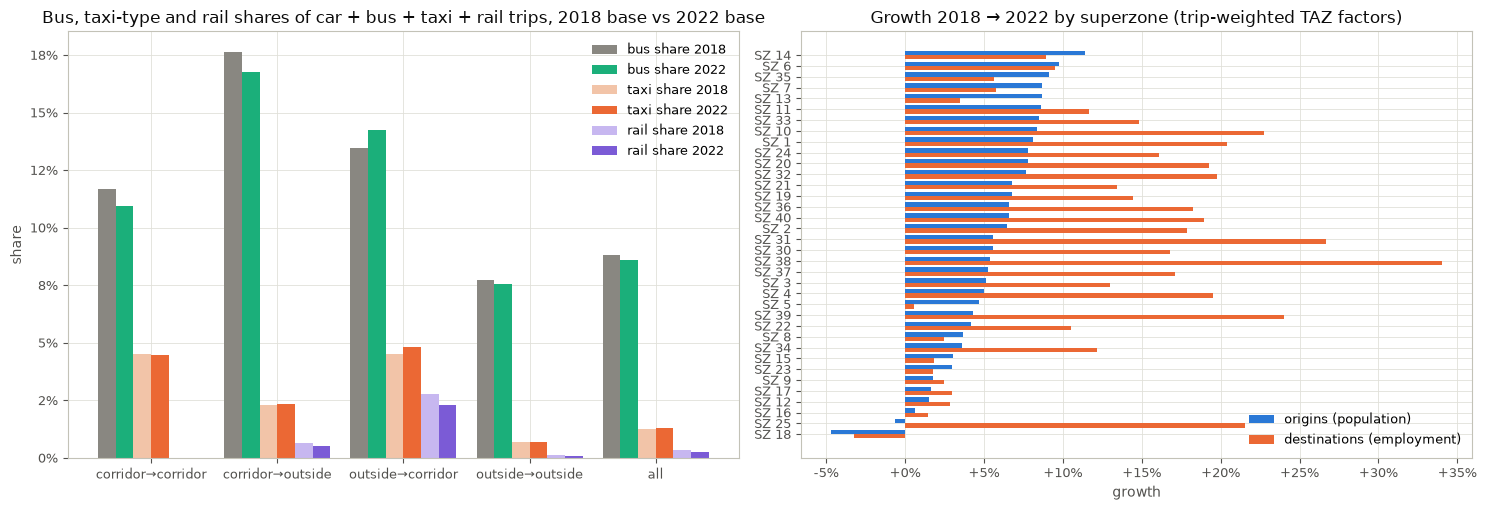

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), facecolor='white')
ax = axes[0]
x = np.arange(len(CLASSES) + 1); w = 0.2
x = np.arange(len(CLASSES) + 1); w = 0.14
for i, (col, color) in enumerate([('bus share 2018', MUTED), ('bus share 2022', AQUA), ('taxi share 2018', '#f2c4a8'), ('taxi share 2022', ORANGE), ('rail share 2018', '#c7b7f0'), ('rail share 2022', PURPLE)]):
    ax.bar(x + (i - 2.5) * w, summ[col].values, width=w, color=color, label=col)
ax.set_xticks(x); ax.set_xticklabels(list(summ.index), color=INK2, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
style_ax(ax, 'Bus, taxi-type and rail shares of car + bus + taxi + rail trips, 2018 base vs 2022 base', None, 'share')
ax.legend(frameon=False, fontsize=9)
ax = axes[1]
order = np.argsort(gf.groupby('SZ')['g_origin'].apply(lambda s: np.average(s, weights=car18.sum(axis=1).values[s.index])).values)
gsz = pd.DataFrame({'SZ': SZ, 'g_origin (car-weighted)': [np.average(g_o[sz_of == z], weights=np.maximum(w_o[sz_of == z], 1e-9)) for z in SZ],
                    'g_dest (car-weighted)': [np.average(g_d[sz_of == z], weights=np.maximum(w_d[sz_of == z], 1e-9)) for z in SZ]}).sort_values('g_origin (car-weighted)')
y = np.arange(len(gsz))
ax.barh(y + 0.2, gsz['g_origin (car-weighted)'] - 1, height=0.4, color=BLUE, label='origins (population)')
ax.barh(y - 0.2, gsz['g_dest (car-weighted)'] - 1, height=0.4, color=ORANGE, label='destinations (employment)')
ax.set_yticks(y); ax.set_yticklabels([f'SZ {int(z)}' for z in gsz['SZ']], fontsize=7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0%}'))
style_ax(ax, 'Growth 2018 → 2022 by superzone (trip-weighted TAZ factors)', 'growth', None)
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout(); save_show(fig, 'three_mode_2022.png')

## Notes

- **Layer content.** `bus_2022_*.csv` = calibrated Public Bus + Matronit only. `taxi_2022_*.csv` = the survey's taxi-type modes grown to 2022. `all_modes_2022_taz.csv` = car + bus + taxi + rail. The first version folded taxi-type into the bus files (`bus_2022_excl_taxi_taz.csv` / `all_three_modes_2022_taz.csv`, now removed).
- **Vintage logic.** Bus cells that took RavKav volumes are the 2022 anchor and are not grown again; the guarded cells (57,051 trips at 2018 survey level, 28 origin × segment cells) grow with their origin's population factor to 60,587; everything else of survey vintage is moved 2018 → 2022 with demographic growth, rail with the observed national ridership series instead — rail recovery lagged and a demographic factor would overstate it.
- **Rail frame.** The survey rail matrix is door-to-door for residents with both ends in the study area (5.1k → 4.1k trips); the 2019 smartcard station-to-station matrix scaled to 2022 is saved beside it (`rail_station_smartcard_2022_taz.csv`) for corridor-loading work, where station TAZs are the right origin. Whether a bus-to-rail traveller sits in both the bus matrix (RavKav journey ending at the station stop) and the station matrix is not yet tested (review §3).
- **TAZ growth factors** with a 2020 base below 500 fall back to the superzone factor, so small zones do not receive forecast noise; large TAZ factors (new residential / employment zones in the BU-2025 forecast) are listed in `growth_factors_taz_2018_2022.csv`.
- **Corridor-bound car trips fall** (outside → corridor −5.8 %) while every other class grows: the BU-2025 forecast puts employment growth in the corridor TAZs below the regional average, and the destination margins carry that. It is a property of the demographic scenario, not of the survey; the HS scenario would move it (see `Demographic_scenario_comparison.ipynb`).
- Frames and coverage caveats of the calibrated bus layer, including the asymmetry of the segmented coverage rule, carry over from `THS_2017_two_mode_matrix.ipynb`.